In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

from matplotlib.path import Path
from skimage.filters import threshold_multiotsu, threshold_otsu
import cv2
from skimage import filters, measure
from scipy.ndimage.morphology import binary_closing
from scipy.ndimage import label

color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
              '#f0e442', '#0072b2', '#d55e00', '#cc79a7']


<ipython-input-1-0bafc8eb2eb8>:11: DeprecationWarning: Please use `binary_closing` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  from scipy.ndimage.morphology import binary_closing


In [2]:
def class_contrast(image, thresholds):
    regions = np.digitize(image, bins=thresholds)
    means = [np.mean(image[regions == i]) for i in range(len(thresholds) + 1)]
    contrast = np.std(means)  # Dispersion des moyennes
    return contrast

def otsu_criterion(image, thresholds):
    """
    Calcule la variance intra-classe totale après seuillage multi-Otsu.
    Plus cette valeur est faible, meilleure est la séparation des classes.
    """
    regions = np.digitize(image, bins=thresholds)
    total_variance = 0
    
    for i in range(len(thresholds) + 1):
        mask = regions == i
        if np.any(mask):
            variance = np.var(image[mask])
            total_variance += variance
    
    return total_variance

def find_elbow_thresholds(image, max_k=5):
    variances = []
    fig, ax = plt.subplots(figsize = (10,10))
    for k in range(1, max_k+1):
        thresholds = threshold_multiotsu(image, classes=k+1)
        segmented = np.digitize(image, bins=thresholds)
        var_inter = np.std([np.mean(image[segmented == i]) for i in range(k+1)])
        variances.append(var_inter)
    
    plt.plot(range(1, max_k+1), variances, marker='o')
    plt.show()
    kneedle = KneeLocator(range(1, max_k+1), variances, curve="concave", direction="increasing")
    return kneedle.elbow

def otsu_detection(nbclasse, image, m_size, sigma_X, sigma_Y, mode_switch, min_nbclass = 2):
    max_interclasse = 0
    min_intraclasse = 1e12
    max_nbclasse = 0
    
    """ blurred_image = cv2.GaussianBlur(image, (m_size, m_size), sigmaX = sigma_X, sigmaY = sigma_Y) """
    blurred_image  = cv2.medianBlur(image, 5)
    
    #Find the best number of classes
    for n in range(min_nbclass, nbclasse + 1):
        thresholds = threshold_multiotsu(blurred_image[image!=0], classes = n)
        if mode_switch == 0:
            contrast = class_contrast(image, thresholds)
            if contrast > max_interclasse:
                max_interclasse = contrast
                max_nbclasse = n
                
        elif mode_switch == 1:
            intra_std = otsu_criterion(image, thresholds)
            if intra_std < min_intraclasse:
                min_intraclasse = intra_std
                max_nbclasse = n
        else:
            raise ValueError("otsu_detection mode_switch must be 0 or 1")
    # max_nbclasse = 5
    return cluster_detection(blurred_image, max_nbclasse)

def contours_to_label_fct(labeled_image, contours, num_features):
    L1 = labeled_image.shape[0]
    L2 = labeled_image.shape[1]
    ##########External contour##########
    contour_to_label = []
    for j, contour in enumerate(contours):  
        external_path = Path(contour)
        for k in range(1,num_features + 1):
            patch = np.argwhere(labeled_image == k)
            inside = external_path.contains_points(patch)
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label.append([j, k])
                # ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=1)
                break
        else: 
            contour_to_label.append([j, -1]) #Si aucun élément n'est contenu dans le contour, c'est un contour interieur    
            # ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="blue", alpha=1)  

    ##########Internal contour##########
    contour_to_label = np.array(contour_to_label)
    mask = contour_to_label[:,1] == -1

    for _, int_id_contour in enumerate(contour_to_label[mask][:,0]):
        for _, (id_contour, idpatch) in enumerate(contour_to_label[~mask]):
            external_path = Path(contours[id_contour])
            inside = external_path.contains_points(contours[int_id_contour])
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label[int_id_contour,1] = idpatch 
                # ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=2, color="green", alpha=1)
                break
        else:
            for point in contours[int_id_contour]:
                y, x = np.floor(point).astype(int)

                neighbors = [(y+1, x), (y-1, x), (y, x+1), (y, x-1)]
                for y_neighbor, x_neighbor in neighbors: 
                    if 0 <= x_neighbor < L1 and 0 <= y_neighbor < L2:
                        label_val = labeled_image[y_neighbor, x_neighbor]
                        if label_val:
                            contour_to_label[int_id_contour, 1] = label_val
                            break

                    
        if contour_to_label[int_id_contour,1] == -1:
            print("A contour is not linked to a cluster, id_contour = {}".format(int_id_contour))
        """     ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=3, color="orange", alpha=1)
        else :
            ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=3, color="green", alpha=1) """
    
    #Change the contour_id to the patch_id since it will be the same in all_contours_to_label and all_contours 
    return contour_to_label

def cluster_detection(blurred_image, nbclass):
    feature_areas = []
    all_contours = []
    all_labeled_image = []
    
    thresholds = threshold_multiotsu(blurred_image[blurred_image!=0], classes = nbclass)#Find the thresholds
    regions = np.digitize(blurred_image, bins=thresholds)
    all_contours_to_label = []
    
    for i in range (0, nbclass):
        # print(i)
        mask = regions == i  # Tolérance pour ignorer uniquement les valeurs très faibles
        masked_image = np.where(mask, 1, -1)

        smoothed_image = filters.gaussian(masked_image, sigma=1) #Allow to fill the possible holes in the clusters
        
        original = smoothed_image
        thres = threshold_otsu(smoothed_image) #Find a threshold between background and the class
        binary = original > thres

        binary_closed = binary_closing(binary, structure=np.ones((2,2))) #Créé les domaines (dilatation + erosion)
        labeled_image, num_features = label(binary_closed)  #Etiquettes les regions 
        feature_areas.extend(np.bincount(labeled_image.ravel())[1:]) #Enregistre la taille de chaque regions (ravel aplati le tableau)
        all_labeled_image.append(labeled_image)

        contours = measure.find_contours(binary_closed, level=0.5)
        all_contours.extend(contours)
    
        ##########Link contours to labeled clusters##########

        contours_to_label = contours_to_label_fct(labeled_image, contours, num_features)
        contours_to_label[:,0] = i
        all_contours_to_label.extend(contours_to_label)  
        
        
        
    return np.array(feature_areas), all_contours


def find_max_patch_size(folderpath, TNoava, L1, L2, nu):
    
    nbclass, msize, sigma, mode_switch = 0,0,0,0
    if nu == 0.6:
        nbclass, msize, sigma, mode_switch = 4, [3], [2], 0
    elif nu == 0.5:
        nbclass, msize, sigma, mode_switch = 5, [5], [3], 1
    elif nu == 0.4:
        nbclass, msize, sigma, mode_switch = 5, [3], [0], 0
    elif nu < 0.4:
        nbclass, msize, sigma, mode_switch = 5, [3], [0], 1
    
    T_patch_size = np.empty(len(TNoava))
    
    for i, Noava in enumerate(TNoava):
        data = np.loadtxt("{}/Snapshots/nav{}.txt".format(folderpath,Noava), comments='#')
        sys = data.reshape(L1, L2).T
        sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV

        feature_areas, all_contours = otsu_detection(nbclass, sys_image_bis, msize, sigma, sigma, mode_switch)

        if len(all_contours) > 600 and nu < 0.5:
            blurred_sys2 = cv2.medianBlur(sys_image_bis, 5) #Supprime le bruit en raplaçant la valeur par la dmedian des voisines
                
            feature_areas, all_contours = otsu_detection(nbclass, blurred_sys2, 7,0,0, mode_switch)
                    
        T_patch_size[i] = np.max(feature_areas)
    
    return T_patch_size

def loghisto(linhisto, nbins = 0):
    data = linhisto
    
    last_non_zero = np.nonzero(data)[0]
    nmax = last_non_zero[-1]
    if nbins == 0:
        nbins = freedman_diaconis_log_bins(data[:nmax])
    
    bins, histo = new_logbins(data[:nmax], nbins) #Transforme les bins lin en bins log
    bin_center = (bins[1:] + bins[:-1])/2
    
    mask = histo != 0
    f_histo = histo[mask]
    f_bin_center = bin_center[mask]
    
    return f_histo, f_bin_center

#   Analyse des patches

##  Comparaison large ava configuration, patch et avalanche

In [ ]:

folderpath = "/data1/DATA_Duplat/Brut/Memory_effects/Me5n12"

L2 = read_parameters(folderpath)[0]
L1 = read_parameters(folderpath)[1]
nu = read_parameters(folderpath)[2]
    

data = np.loadtxt("{}/random_large.txt".format(folderpath), comments = '#', usecols = [0,2], dtype = int)

TNoava, Ts = data[:,0], data[:, 1]

T_patch_size = np.empty(len(data))

In [ ]:
for i, Noava in enumerate(TNoava[:1000]):
    data = np.loadtxt("{}/Snapshots/nav{}.txt".format(folderpath,Noava), comments='#')
    sys = data.reshape(L1, L2).T
    sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255 pour OpenCV

    feature_areas, all_contours = otsu_detection(nbclass, sys_image_bis, msize, sigma, sigma, mode_switch)

    if len(all_contours) > 600 and nu < 0.5:
        blurred_sys2 = cv2.medianBlur(sys_image_bis, 5) #Supprime le bruit en raplaçant la valeur par la dmedian des voisines
            
        feature_areas, all_contours = otsu_detection(nbclass, blurred_sys2, 7,0,0, mode_switch)
                
    T_patch_size[i] = np.max(feature_areas)
#%%
np.savez("data.npz", 
         T_patch_size=T_patch_size, 
         Ts=Ts)
#%%


In [8]:
data = np.load("data.npz", allow_pickle=True)
T_patch_size = data["T_patch_size"]
Ts = data["Ts"]

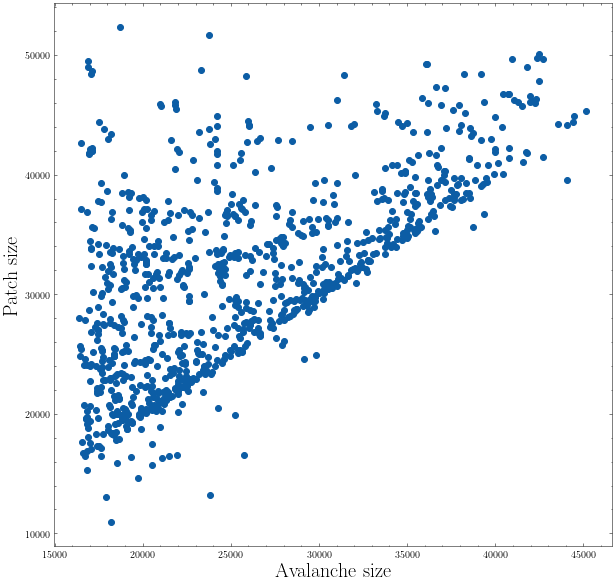

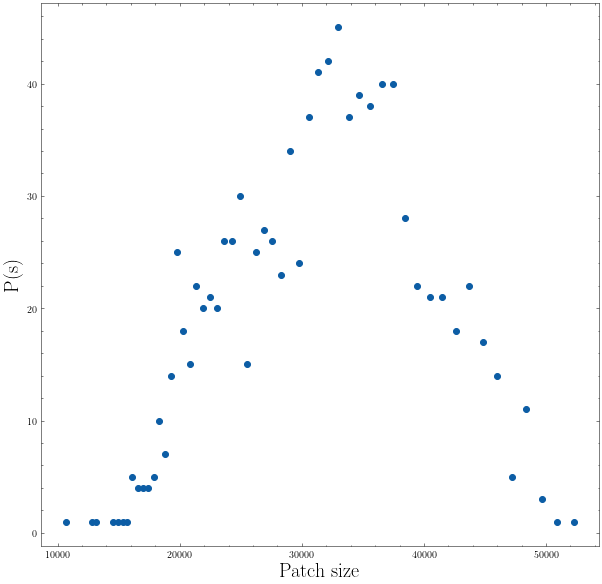

In [9]:

islice = slice(0,1000)
ratio = Ts[islice]/T_patch_size[islice]

histo, bins = np.histogram(ratio)

fig, ax = plt.subplots(figsize = (10,10))
ax.scatter(Ts[islice], T_patch_size[islice])
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Avalanche size', fontsize = 20)
ax.set_ylabel('Patch size', fontsize = 20)
plt.show()


histo2, bins2 = np.histogram(T_patch_size[:1000], bins = np.logspace(np.log(1), np.log(L1*L2), 1000))

mask = histo2!=0
fig, ax = plt.subplots(figsize = (10,10))
ax.scatter(bins2[:-1][mask], histo2[mask])
ax.set_xlabel('Patch size', fontsize = 20)
ax.set_ylabel('P(s)', fontsize = 20)
# ax.set_xscale('log')
# ax.set_yscale('log')
plt.show()

### Comparaison N/10 and N/1 try


##  Comparaison taille patch et max size avalanche depending on the configuration

In [67]:
folderpath = "/data1/DATA_Duplat/Brut/Memory_effects/Me7n1"
L2 = read_parameters(folderpath)[0]
L1 = read_parameters(folderpath)[1]
nu = read_parameters(folderpath)[2]

# TNoava_large_1, Ts_large_1 = np.loadtxt("{}/random_large.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_large_1 = [L1*L2] *len(TNoava_large_1)

# TNoava_rd_1, Ts_rd_1 = np.loadtxt("{}/random_random.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_rd_1 = [L1*L2] *len(TNoava_rd_1)

TNoava_small_1, Ts_small_1 = np.loadtxt("{}/random_small.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_small_1 = [L1*L2] *len(TNoava_small_1)


In [68]:
folderpath = "/data1/DATA_Duplat/Brut/Memory_effects/Me7n2"
L2 = read_parameters(folderpath)[0]
L1 = read_parameters(folderpath)[1]
nu = read_parameters(folderpath)[2]

TNoava_large_2, Ts_large_2 = np.loadtxt("{}/random_large.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_large_2 = find_max_patch_size(folderpath, TNoava_large_2, L1, L2, nu)

TNoava_rd_2, Ts_rd_2 = np.loadtxt("{}/random_random.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_rd_2 = find_max_patch_size(folderpath, TNoava_rd_2, L1, L2, nu)

TNoava_small_2, Ts_small_2 = np.loadtxt("{}/random_small.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_small_2 = find_max_patch_size(folderpath, TNoava_small_2, L1, L2, nu)

In [69]:
folderpath = "/data1/DATA_Duplat/Brut/Memory_effects/Me7n3"
L2 = read_parameters(folderpath)[0]
L1 = read_parameters(folderpath)[1]
nu = read_parameters(folderpath)[2]

TNoava_large_3, Ts_large_3 = np.loadtxt("{}/random_large.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_large_3 = find_max_patch_size(folderpath, TNoava_large_3, L1, L2, nu)

# TNoava_rd_3, Ts_rd_3 = np.loadtxt("{}/random_random.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_rd_3 = find_max_patch_size(folderpath, TNoava_rd_3, L1, L2, nu)

TNoava_small_3, Ts_small_3 = np.loadtxt("{}/random_small.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_small_3 = find_max_patch_size(folderpath, TNoava_small_3, L1, L2, nu)

In [70]:
folderpath = "/data1/DATA_Duplat/Brut/Memory_effects/Me7n4"
L2 = read_parameters(folderpath)[0]
L1 = read_parameters(folderpath)[1]
nu = read_parameters(folderpath)[2]

# TNoava_large_4, Ts_large_4 = np.loadtxt("{}/random_large.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_large_4 = find_max_patch_size(folderpath, TNoava_large_4, L1, L2, nu)

# TNoava_rd_4, Ts_rd_4 = np.loadtxt("{}/random_random.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_rd_4 = find_max_patch_size(folderpath, TNoava_rd_4, L1, L2, nu)

TNoava_small_4, Ts_small_4 = np.loadtxt("{}/random_small.txt".format(folderpath), comments = '#', usecols = [0,8], dtype = int, unpack = True)
# Tpatch_small_4 = find_max_patch_size(folderpath, TNoava_small_4, L1, L2, nu)

In [56]:
# np.savez("data_max_size.npz", 
#          TNoava_small_1 = TNoava_small_1, Ts_small_1 = Ts_small_1, Tpatch_small_1 = Tpatch_small_1,
#          TNoava_rd_1 = TNoava_rd_1, Ts_rd_1 = Ts_rd_1, Tpatch_rd_1 = Tpatch_rd_1,
#          TNoava_large_1 = TNoava_large_1, Ts_large_1 = Ts_large_1, Tpatch_large_1 = Tpatch_large_1,
         
#          TNoava_small_2 = TNoava_small_2, Ts_small_2 = Ts_small_2, Tpatch_small_2 = Tpatch_small_2,
#          TNoava_rd_2 = TNoava_rd_2, Ts_rd_2 = Ts_rd_2, Tpatch_rd_2 = Tpatch_rd_2,
#          TNoava_large_2 = TNoava_large_2, Ts_large_2 = Ts_large_2, Tpatch_large_2 = Tpatch_large_2,
         
#          TNoava_small_3 = TNoava_small_3, Ts_small_3 = Ts_small_3, Tpatch_small_3 = Tpatch_small_3,
#          TNoava_rd_3 = TNoava_rd_3, Ts_rd_3 = Ts_rd_3, Tpatch_rd_3 = Tpatch_rd_3,
#          TNoava_large_3 = TNoava_large_3, Ts_large_3 = Ts_large_3, Tpatch_large_3 = Tpatch_large_3,
         
#          TNoava_small_4 = TNoava_small_4, Ts_small_4 = Ts_small_4,Tpatch_small_4 = Tpatch_small_4
#          TNoava_rd_4 = TNoava_rd_4, Ts_rd_4 = Ts_rd_4, Tpatch_rd_1 = Tpatch_rd_4,
#          TNoava_large_4 = TNoava_large_4, Ts_large_4 = Ts_large_4, Tpatch_large_4 = Tpatch_large_4)

np.savez("data_max_size.npz", 
         TNoava_small_1 = TNoava_small_1, Ts_small_1 = Ts_small_1, Tpatch_small_1 = Tpatch_small_1,

         
         TNoava_small_2 = TNoava_small_2, Ts_small_2 = Ts_small_2, Tpatch_small_2 = Tpatch_small_2,
         TNoava_rd_2 = TNoava_rd_2, Ts_rd_2 = Ts_rd_2, Tpatch_rd_2 = Tpatch_rd_2,
         TNoava_large_2 = TNoava_large_2, Ts_large_2 = Ts_large_2, Tpatch_large_2 = Tpatch_large_2,
         
         TNoava_small_3 = TNoava_small_3, Ts_small_3 = Ts_small_3, Tpatch_small_3 = Tpatch_small_3,
         TNoava_large_3 = TNoava_large_3, Ts_large_3 = Ts_large_3, Tpatch_large_3 = Tpatch_large_3,
         
         TNoava_small_4 = TNoava_small_4, Ts_small_4 = Ts_small_4,Tpatch_small_4 = Tpatch_small_4)

In [2]:
data = np.load("data_max_size.npz")
TNoava_small_1 = data["TNoava_small_1"]
Ts_small_1     = data["Ts_small_1"]
Tpatch_small_1 = data["Tpatch_small_1"]

# TNoava_rd_1    = data["TNoava_rd_1"]
# Ts_rd_1        = data["Ts_rd_1"]
# Tpatch_rd_1    = data["Tpatch_rd_1"]

# TNoava_large_1 = data["TNoava_large_1"]
# Ts_large_1     = data["Ts_large_1"]
# Tpatch_large_1 = data["Tpatch_large_1"]

# Bloc 2
TNoava_small_2 = data["TNoava_small_2"]
Ts_small_2     = data["Ts_small_2"]
Tpatch_small_2 = data["Tpatch_small_2"]

TNoava_rd_2    = data["TNoava_rd_2"]
Ts_rd_2        = data["Ts_rd_2"]
Tpatch_rd_2    = data["Tpatch_rd_2"]

TNoava_large_2 = data["TNoava_large_2"]
Ts_large_2     = data["Ts_large_2"]
Tpatch_large_2 = data["Tpatch_large_2"]

# Bloc 3
TNoava_small_3 = data["TNoava_small_3"]
Ts_small_3     = data["Ts_small_3"]
Tpatch_small_3 = data["Tpatch_small_3"]

# TNoava_rd_3    = data["TNoava_rd_3"]
# Ts_rd_3        = data["Ts_rd_3"]
# Tpatch_rd_3    = data["Tpatch_rd_3"]

TNoava_large_3 = data["TNoava_large_3"]
Ts_large_3     = data["Ts_large_3"]
Tpatch_large_3 = data["Tpatch_large_3"]

# Bloc 4
TNoava_small_4 = data["TNoava_small_4"]
Ts_small_4     = data["Ts_small_4"]
Tpatch_small_4 = data["Tpatch_small_4"]

# TNoava_rd_4    = data["TNoava_rd_4"]
# Ts_rd_4        = data["Ts_rd_4"]
# Tpatch_rd_4    = data["Tpatch_rd_4"]

# TNoava_large_4 = data["TNoava_large_4"]
# Ts_large_4     = data["Ts_large_4"]
# Tpatch_large_4 = data["Tpatch_large_4"]

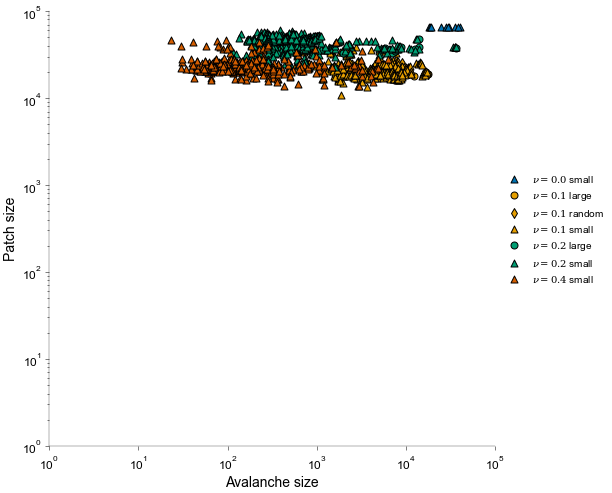

In [3]:
with plt.style.context(spstyle.get_style('nature-reviews')):

    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (8,8))
    # ax.scatter(Ts_large_1, TNoava_large_1, c = color_list[5], marker = 'o', label = r"$\nu = 0.0$ large")
    # ax.scatter(Ts_rd_1, TNoava_rd_1, c = color_list[5], marker = 'd', label = r"$\nu = 0.0$ random")
    ax.scatter(Ts_small_1, Tpatch_small_1, c = color_list[5], marker = '^', label = r"$\nu = 0.0$ small")

    ax.scatter(Ts_large_2, Tpatch_large_2, c = color_list[1], marker = 'o', label = r"$\nu = 0.1$ large")
    ax.scatter(Ts_rd_2, Tpatch_rd_2,  c = color_list[1], marker = 'd', label = r"$\nu = 0.1$ random")
    ax.scatter(Ts_small_2, Tpatch_small_2,  c = color_list[1], marker = '^', label = r"$\nu = 0.1$ small")

    ax.scatter(Ts_large_3, Tpatch_large_3, c = color_list[3], marker = 'o', label = r"$\nu = 0.2$ large")
    # ax.scatter(Ts_rd_3, TNoava_rd_3, c = color_list[3], marker = 'd', label = r"$\nu = 0.2$ random")
    ax.scatter(Ts_small_3, Tpatch_small_3, c = color_list[3], marker = '^', label = r"$\nu = 0.2$ small")

    # ax.scatter(Ts_large_4, TNoava_large_4, c = color_list[6], marker = 'o', label = r"$\nu = 0.4$ large")
    # ax.scatter(Ts_rd_4, TNoava_rd_4, c = color_list[6], marker = 'd', label = r"$\nu = 0.4$ random")
    ax.scatter(Ts_small_4, Tpatch_small_4, c = color_list[6], marker = '^', label = r"$\nu = 0.4$ small")

    ax.set_xlabel("Avalanche size")
    ax.set_ylabel("Patch size")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_xlim(1,1e5)
    ax.set_ylim(1,1e5)
    plt.show()

In [73]:
linbins = np.arange(0,(256*256)+1)
bins_center = (bins[:-1] + bins[1:])/2

hist_small_1, bins_center_small_1 = loghisto(np.histogram(Ts_small_1, bins = linbins)[0], nbins = 10)
# hist_rd_1, bins_center_rd_1 = loghisto(np.histogram(Ts_rd_1, bins = linbins)[0], nbins = 20)
# hist_large_1, bins_center_large_1 = loghisto(np.histogram(Ts_large_1, bins = linbins)[0], nbins = 20)

hist_small_2, bins_center_small_2 = loghisto(np.histogram(Ts_small_2, bins = linbins)[0], nbins = 10)
hist_rd_2, bins_center_rd_2 = loghisto(np.histogram(Ts_rd_2, bins = linbins)[0], nbins = 20)
hist_large_2, bins_center_large_2 = loghisto(np.histogram(Ts_large_2, bins = linbins)[0], nbins = 10)

hist_small_3, bins_center_small_3 = loghisto(np.histogram(Ts_small_3, bins = linbins)[0], nbins = 10)
# hist_rd_3, bins_center_rd_3 = loghisto(np.histogram(Ts_rd_3, bins = linbins)[0], nbins = 20)
hist_large_3, bins_center_large_3 = loghisto(np.histogram(Ts_large_3, bins = linbins)[0], nbins = 10)

Txfit_small_3, Tyfit_small_3, Ttau_s_small_3, Tperr_s_small_3 = PDF_fitting([hist_small_3], [bins_center_small_3], [200], [5e-10], [0.2])

hist_small_4, bins_center_small_4 = loghisto(np.histogram(Ts_small_4, bins = linbins)[0], nbins = 10)
# hist_rd_4, bins_center_rd_4 = loghisto(np.histogram(Ts_rd_4, bins = linbins)[0], nbins = 20)
# hist_large_4, bins_center_large_4 = loghisto(np.histogram(Ts_large_4, bins = linbins)[0], nbins = 20)

Txfit_small_4, Tyfit_small_4, Ttau_s_small_4, Tperr_s_small_4 = PDF_fitting([hist_small_4], [bins_center_small_4], [100], [1e-10], [0.4])


0.9272039839336453
0.9760575770546036


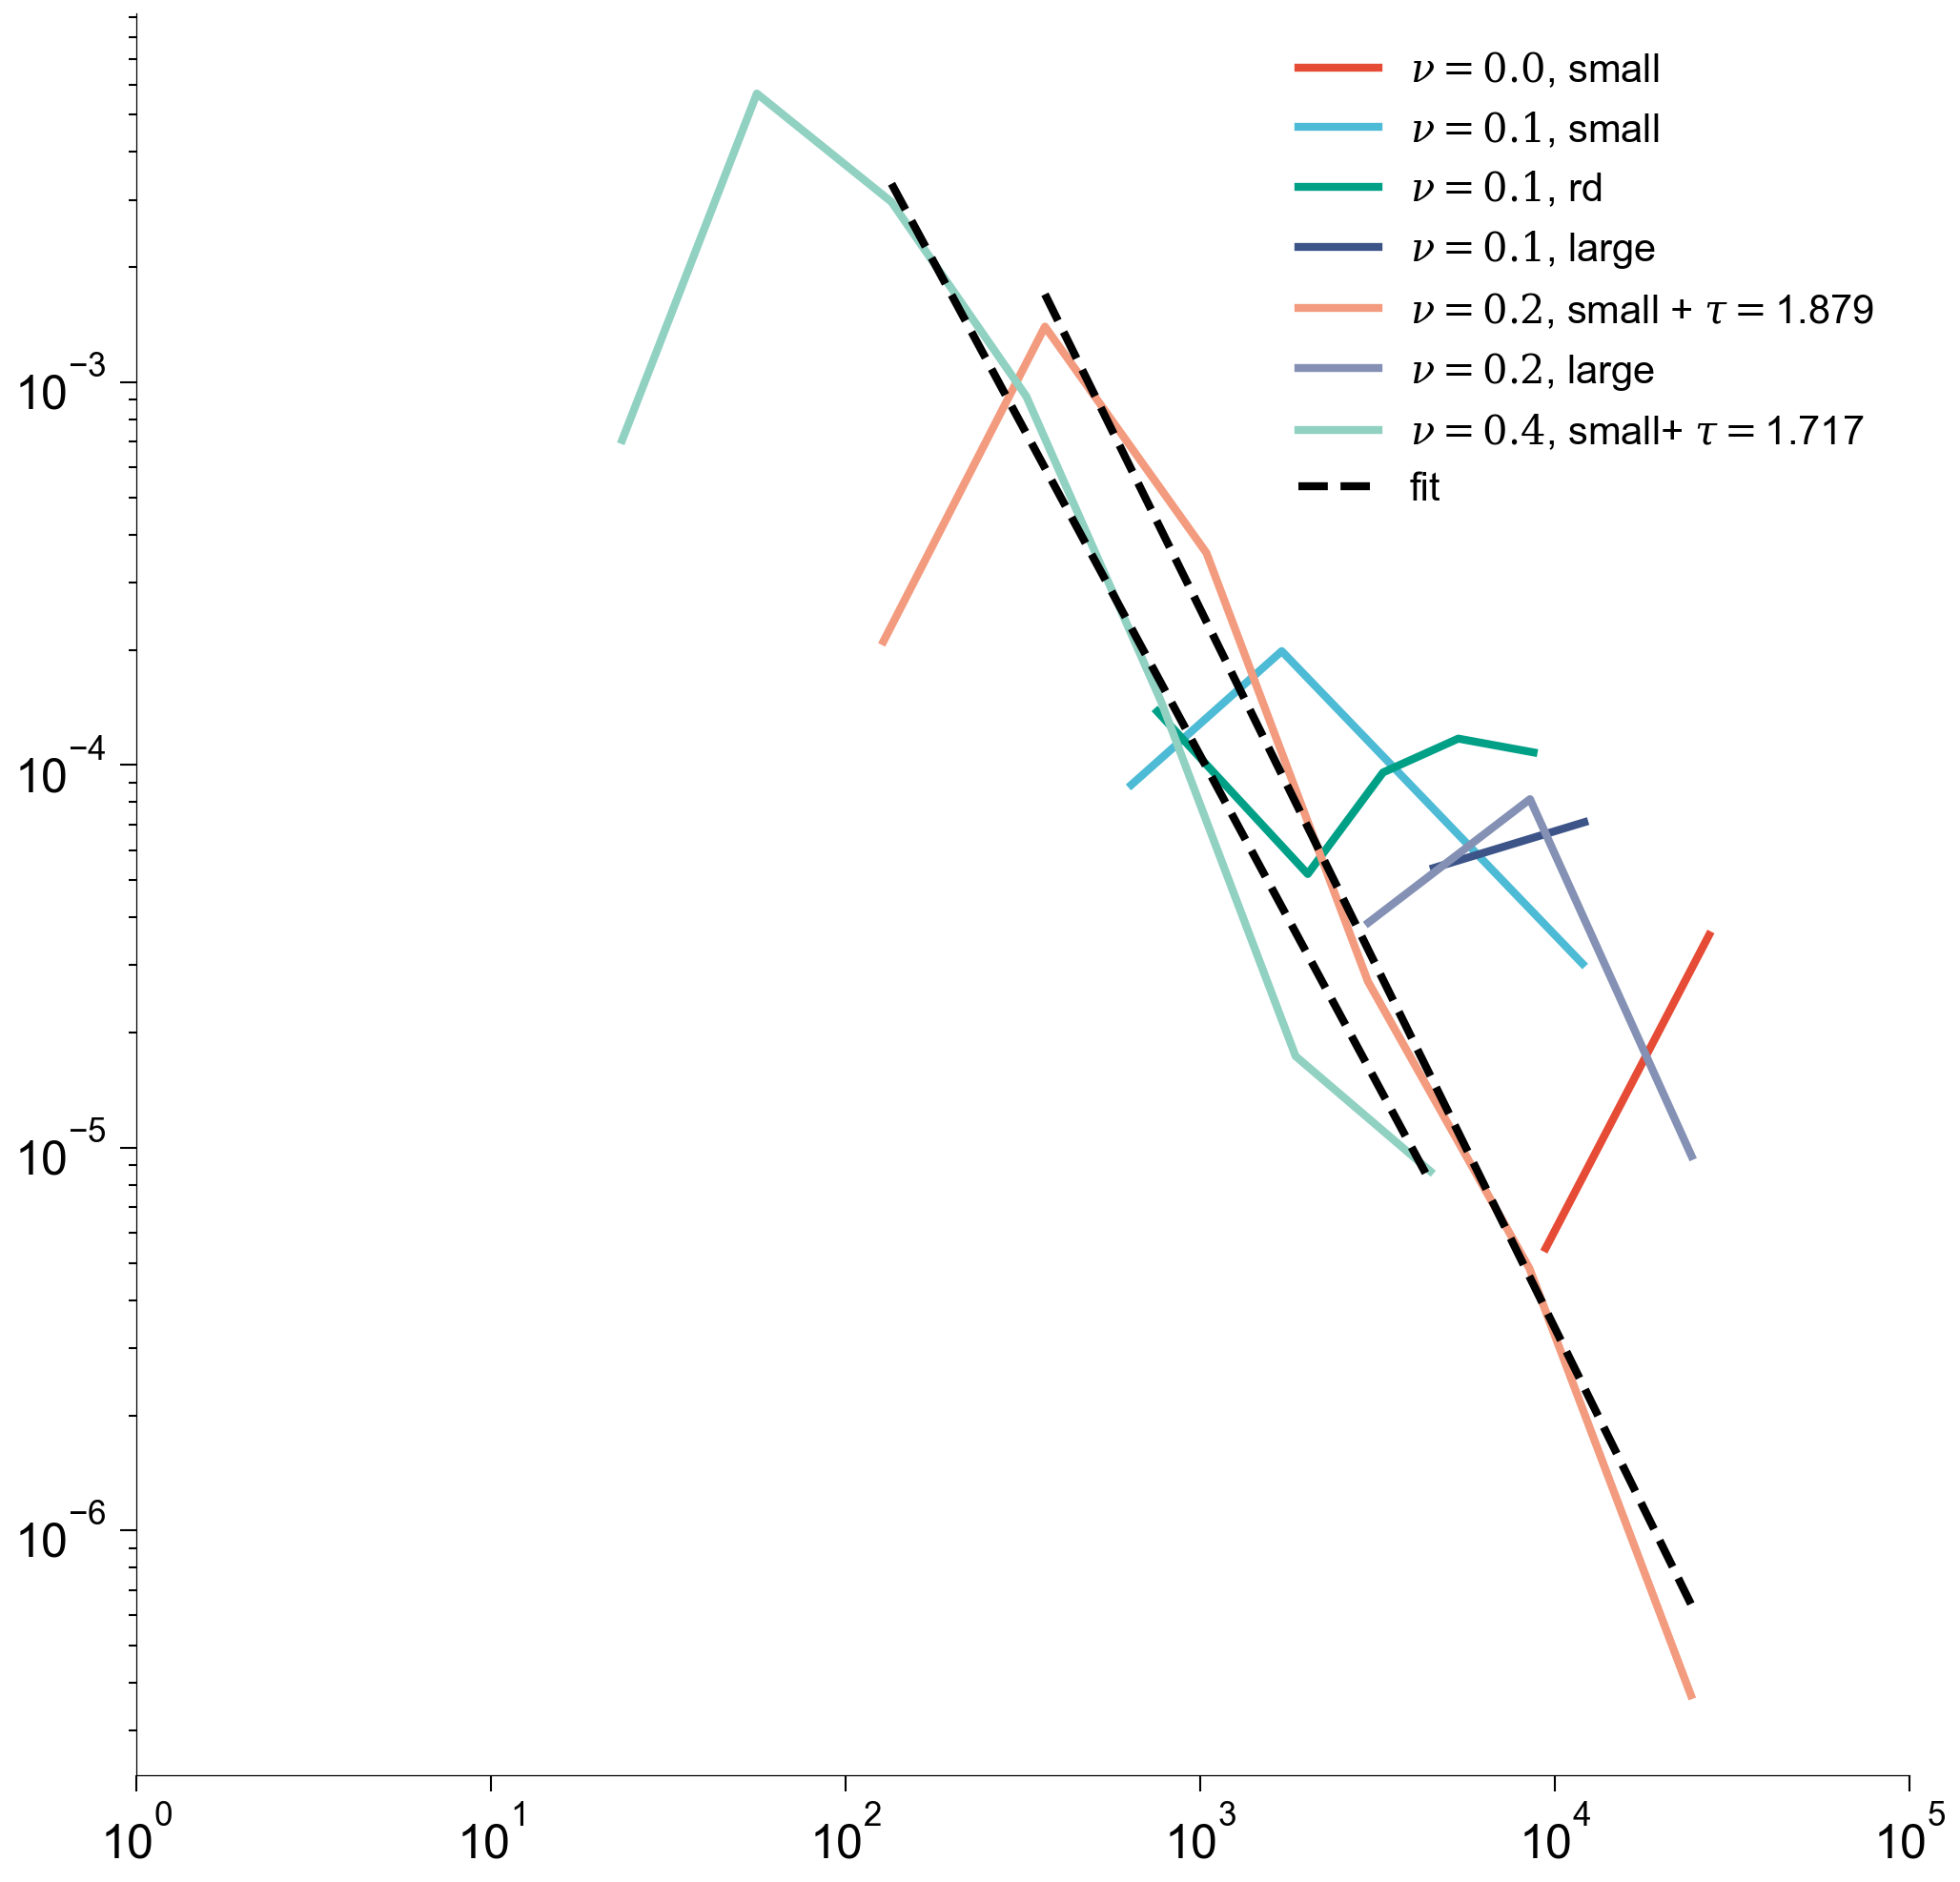

In [74]:
with plt.style.context(spstyle.get_style('nature-reviews')):

    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (8,8))
    ax.plot(bins_center_small_1, hist_small_1, label = r"$\nu = 0.0$, small")
    # ax.plot(bins_center, hist_rd_1)
    # ax.plot(bins_center, hist_large_1)
    
    ax.plot(bins_center_small_2, hist_small_2, label = r"$\nu = 0.1$, small")
    ax.plot(bins_center_rd_2, hist_rd_2, label = r"$\nu = 0.1$, rd")
    ax.plot(bins_center_large_2, hist_large_2, label = r"$\nu = 0.1$, large")
    
    ax.plot(bins_center_small_3, hist_small_3, label = r"$\nu = 0.2$, small + $\tau = $" + "{}".format(-Ttau_s_small_3[0]))
    # ax.plot(bins_center, hist_rd_3)
    ax.plot(bins_center_large_3, hist_large_3, label = r"$\nu = 0.2$, large")
    
    ax.plot(bins_center_small_4, hist_small_4, label = r"$\nu = 0.4$, small+ $\tau = $" + "{}".format(-Ttau_s_small_4[0]))
    # ax.plot(bins_center, hist_rd_4)
    # ax.plot(bins_center, hist_large_4)
    
    ax.plot(Txfit_small_3[0], Tyfit_small_3[0], ls = '--', c = 'k')
    ax.plot(Txfit_small_4[0], Tyfit_small_4[0], ls = '--', c = 'k', label = 'fit')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1,1e5)
    plt.legend()
    
    plt.show()
    


## Evolution patch au cours du temps

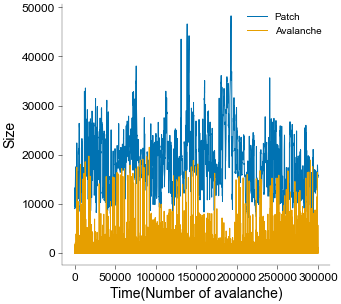

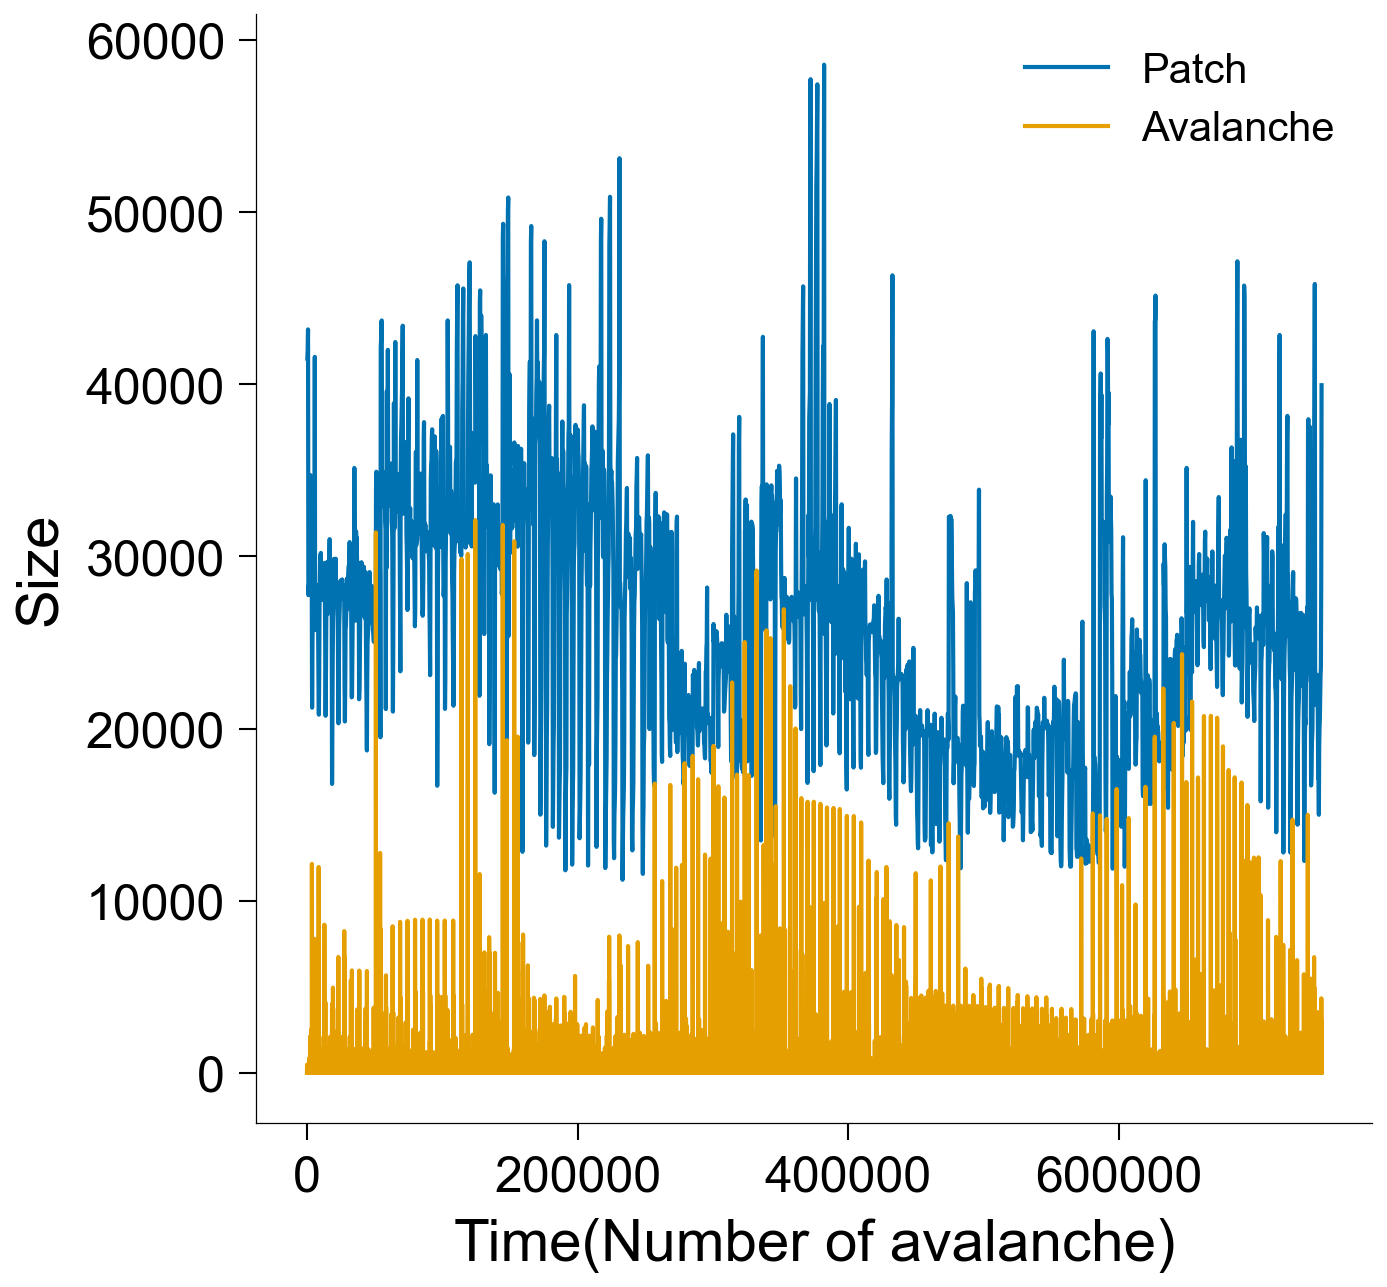

/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


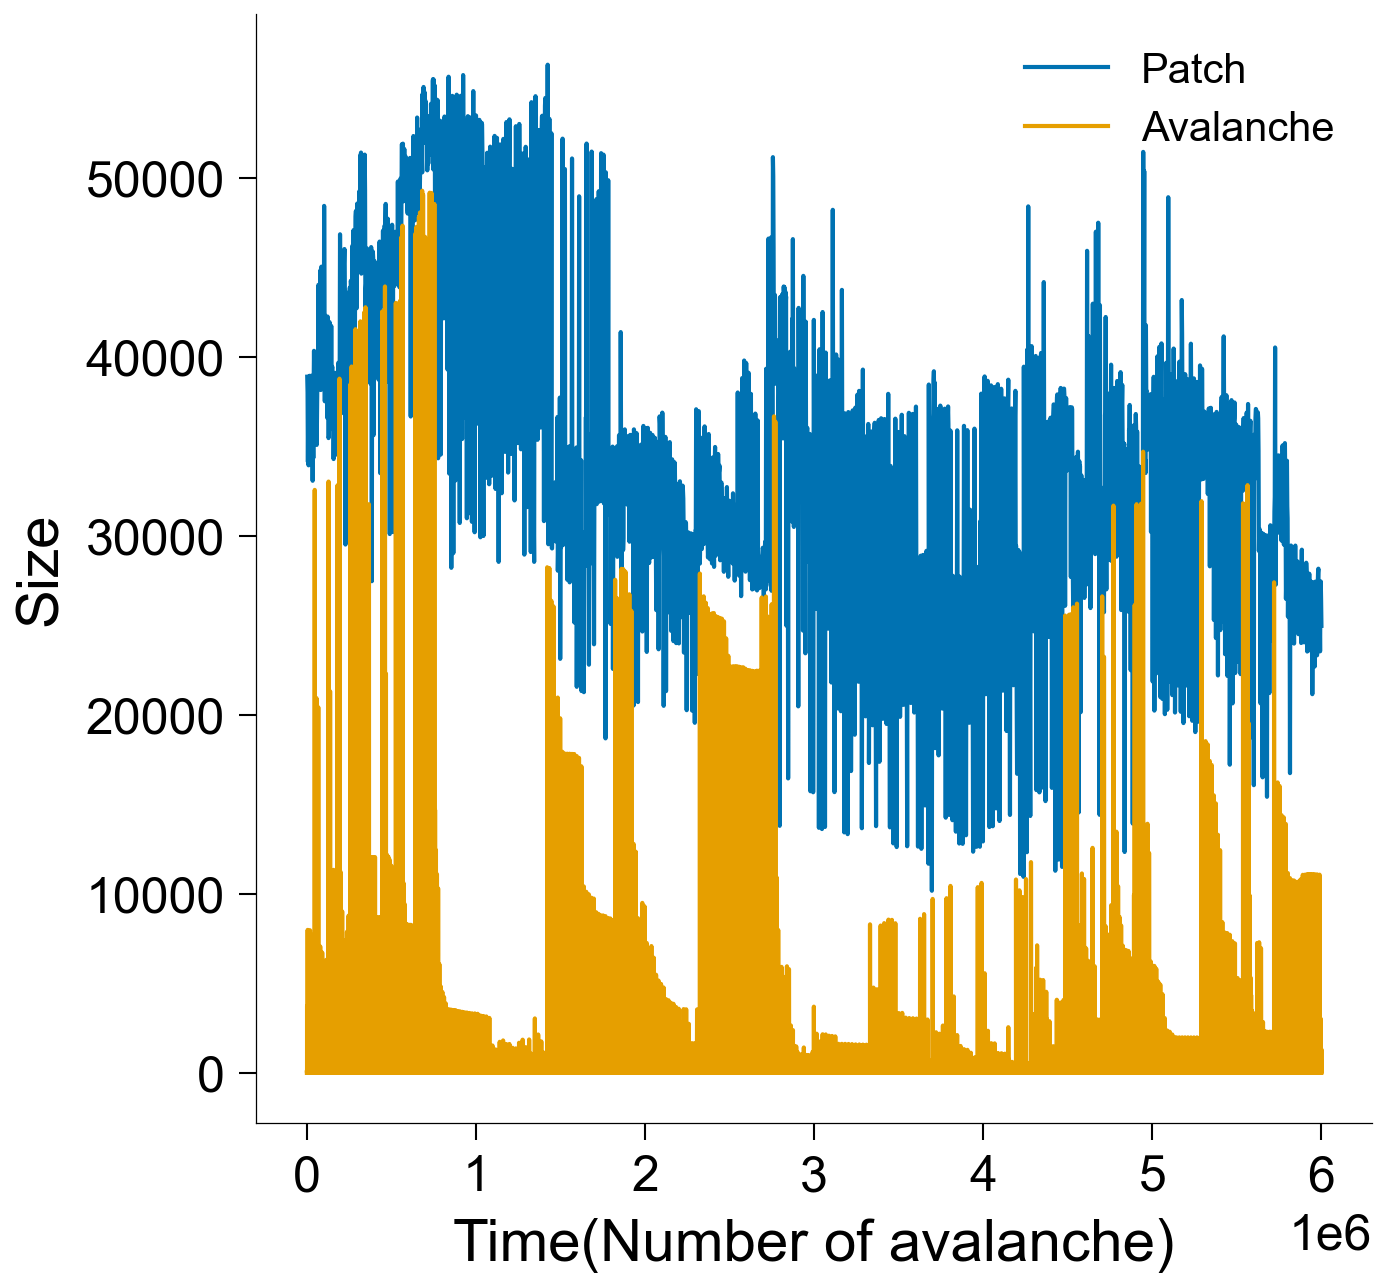

In [3]:
for i in range(1,4):
    folder = "/data1/DATA_Duplat/Brut/Memory_effects/Me8n{}".format(i)
    time_series = np.loadtxt("{}/Snap_analysis.txt".format(folder), comments="#",max_rows= 3000)
    Nava = time_series[:, 0]
    patch_size = time_series[:, 1]

    avalanchesize = read_gz_with_pandas_nrows("{}/Avalanche_outputB.gz".format(folder), nrows = Nava[-1], cols = [1])
    with plt.style.context(spstyle.get_style('nature-reviews')):
        plt.rcParams['font.family'] = 'Arial' 
        
        fig, ax = plt.subplots(figsize = (4.8,4.8))
        ax.plot(Nava, patch_size, lw = 1, c = color_list[5], label = "Patch")
        ax.plot(avalanchesize, lw = 1, c = color_list[1], label = "Avalanche")
        ax.set_xlabel("Time(Number of avalanche)")
        ax.set_ylabel("Size")
        ax.legend()
        plt.show()

In [2]:

folder = "/data1/DATA_Duplat/Brut/Memory_effects/Me8n3"
time_series = np.loadtxt("{}/Snap_analysis.txt".format(folder), comments="#",max_rows= 1500)
Nava = time_series[:, 0]
patch_size = time_series[:, 1]

avalanchesize = read_gz_with_pandas_nrows("{}/Avalanche_outputB.gz".format(folder), nrows = Nava[-1], cols = [1])


In [3]:
filtered_signal = moving_avg(patch_size, window_size = 20)

histo, bins = np.histogram(filtered_signal)

/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


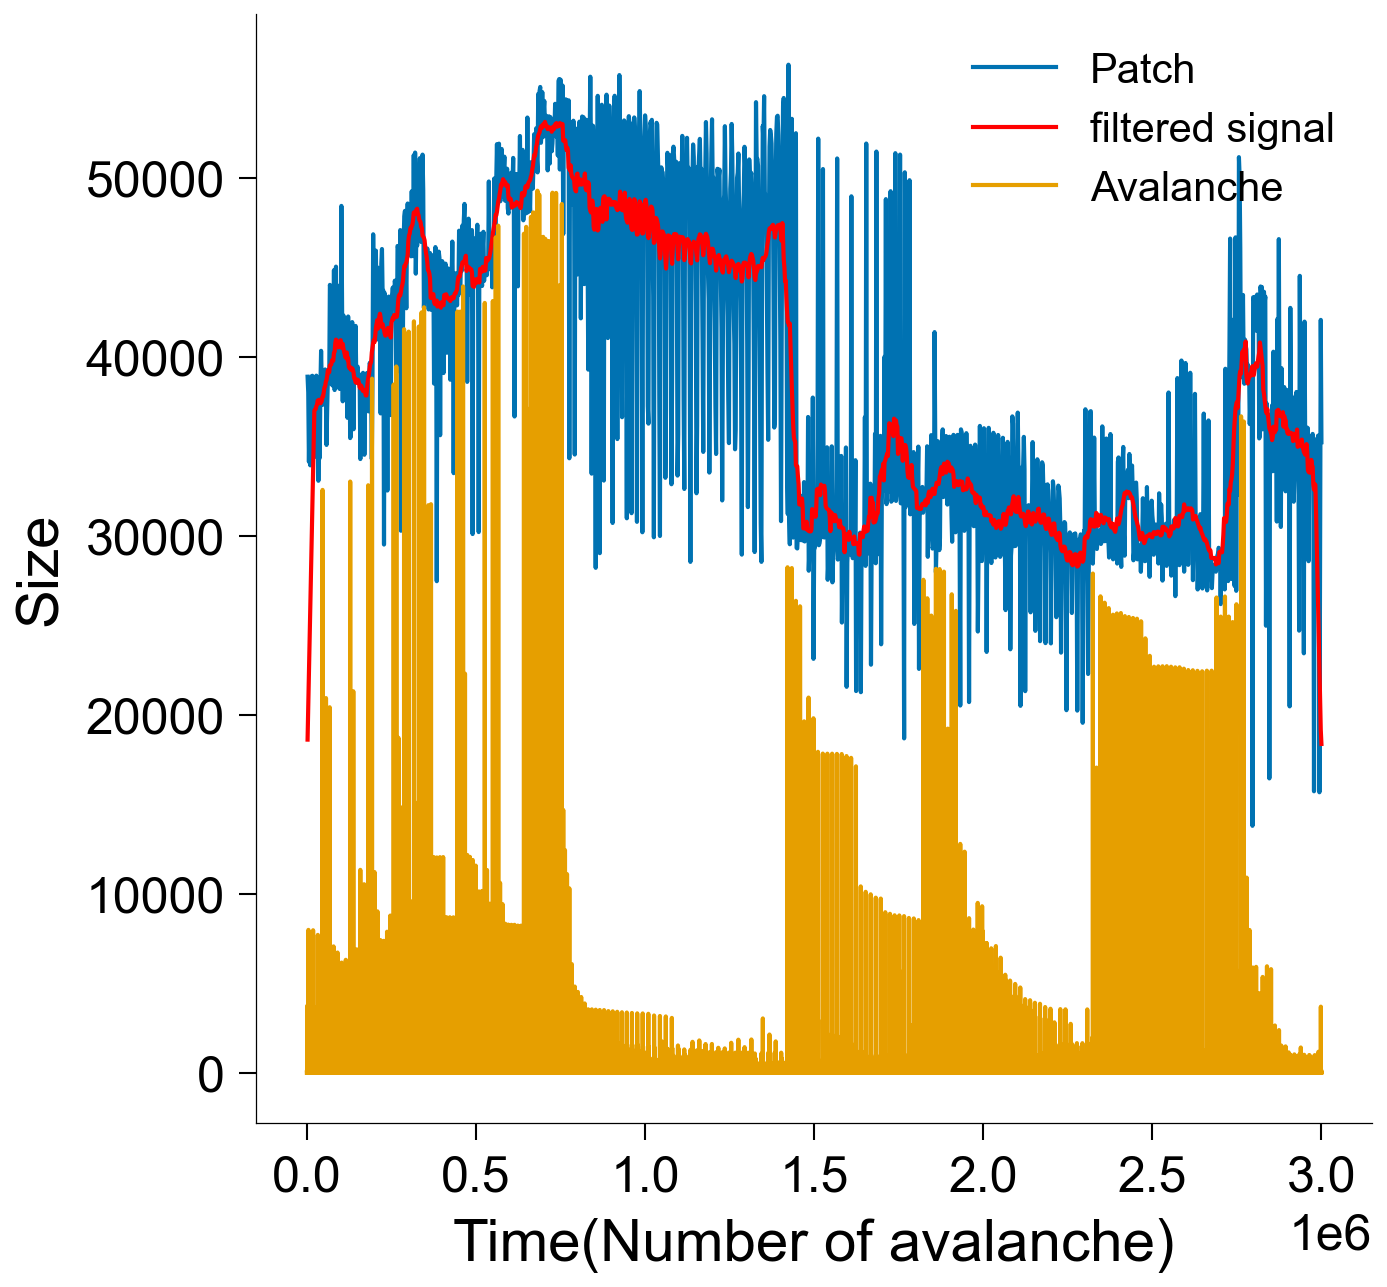

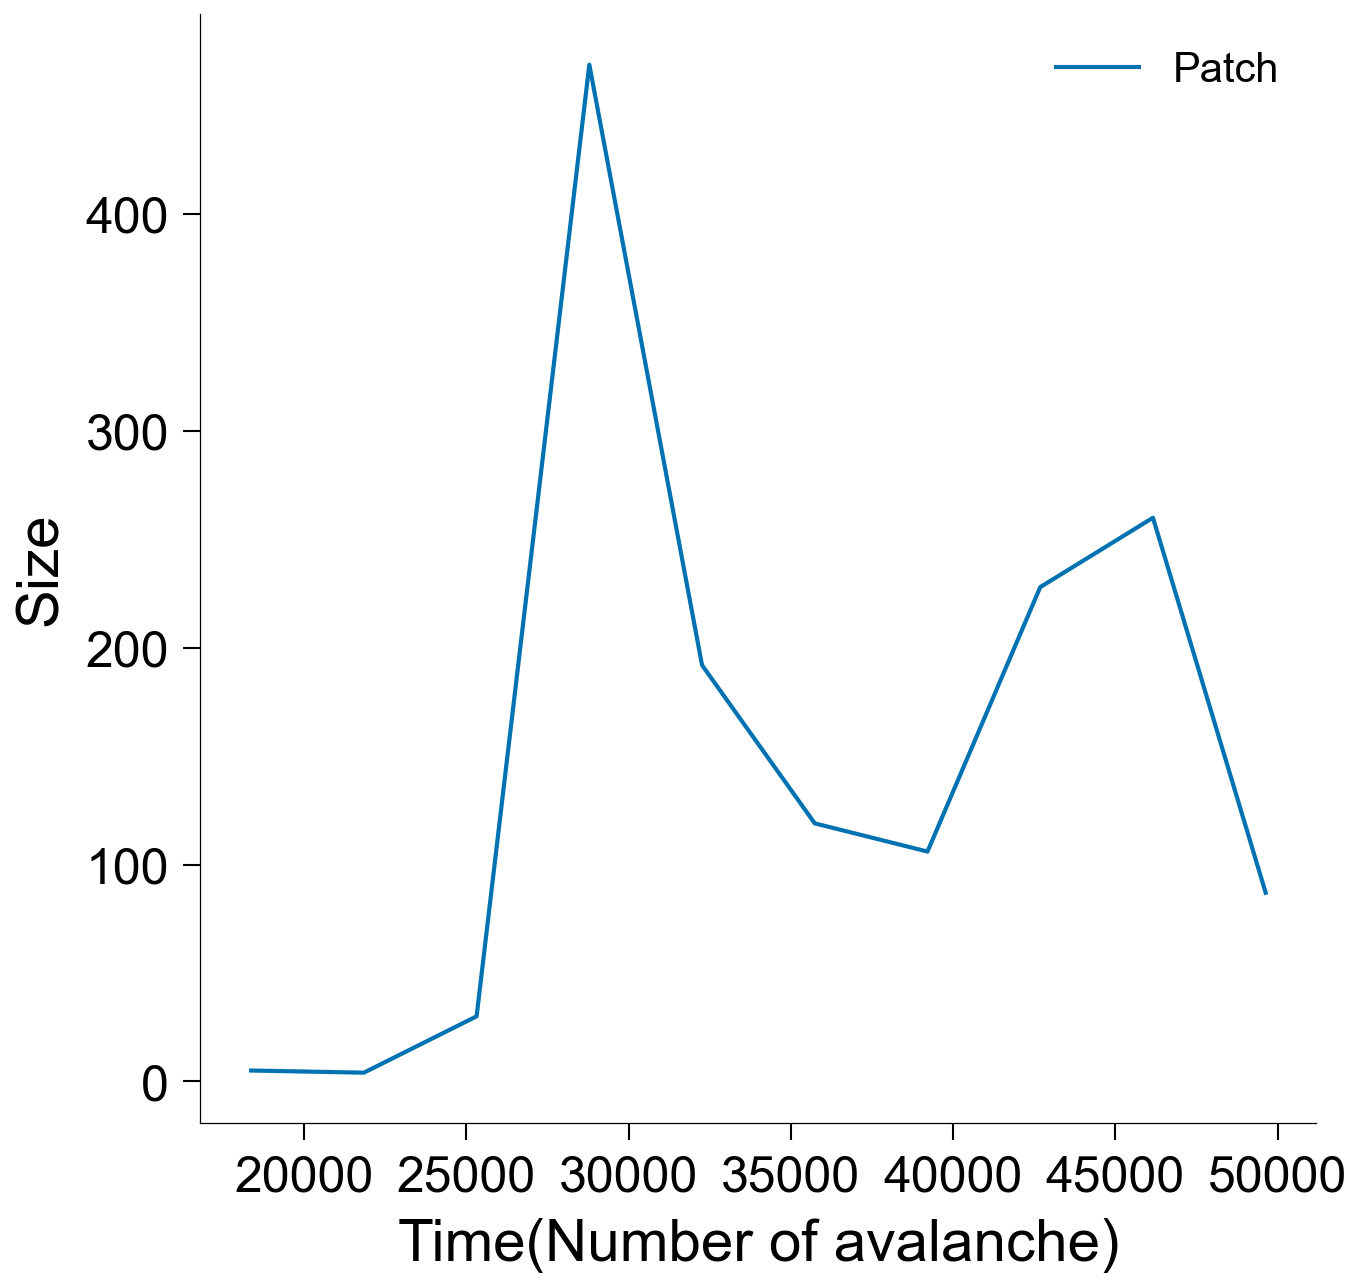

In [6]:

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    
    fig, ax = plt.subplots(figsize = (4.8,4.8))
    ax.plot(Nava, patch_size, lw = 1, c = color_list[5], label = "Patch")
    ax.plot(Nava, filtered_signal, lw = 1, c = "r", label = "filtered signal")
    ax.plot(avalanchesize, lw = 1, c = color_list[1], label = "Avalanche")
    ax.set_xlabel("Time(Number of avalanche)")
    ax.set_ylabel("Size")
    # ax.set_yscale('log')
    ax.legend()
    plt.show()
    
    fig, ax = plt.subplots(figsize = (4.8,4.8))
    ax.plot(bins[:-1], histo, lw = 1, c = color_list[5], label = "Patch")
    ax.set_xlabel("Time(Number of avalanche)")
    ax.set_ylabel("Size")
    ax.legend()
    plt.show()